# Database Connection

In [25]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Alok@12&kumar#@",
    database="railtel"
)

print("Connected")

Connected


In [26]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [27]:
query = "SHOW TABLES"
tables = pd.read_sql(query, conn)

print(tables)

                   Tables_in_railtel
0        adva_network_csv_import_log
1                              alarm
2                      alarm_library
3                           bgp_link
4                   bgp_link_history
5               bgp_link_history_old
6                     bgp_link_stage
7                 bios_configuration
8             bios_configuration_aud
9                      bundle_detail
10                    bundle_mapping
11                         call_flow
12                call_flow_category
13                    call_flow_meta
14                  call_flow_status
15              call_flow_status_aud
16                       ckt_id_info
17                    cluster_tenant
18                              cnfc
19                    cnfc_parameter
20                      cnfc_service
21                             cnfcd
22                              cnfd
23                commissioning_flow
24                 commissioning_job
25             commissioning_job_aud
2

C:\Users\HP\AppData\Local\Temp\ipykernel_20716\1890423291.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query, conn)


In [28]:
import pandas as pd

tables = pd.read_sql("SHOW TABLES", conn)
table_list = tables['Tables_in_railtel'].tolist()

with open("schema_output.txt", "w") as f:
    for table in table_list:
        try:
            cols = pd.read_sql(f"DESCRIBE `{table}`", conn)

            f.write("\n==============================\n")
            f.write(f"Table: {table}\n")
            f.write(f"Columns: {list(cols['Field'])}\n")

        except Exception as e:
            f.write(f"Error reading table {table}: {e}\n")

print("All 143 tables saved to schema_output.txt")

C:\Users\HP\AppData\Local\Temp\ipykernel_20716\3482341842.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql("SHOW TABLES", conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_20716\3482341842.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cols = pd.read_sql(f"DESCRIBE `{table}`", conn)


All 143 tables saved to schema_output.txt


# FILTER REQUIRED TABLES
## alarm
## network_element
## bgp_link
## lldp_link
## isis_link
## ospf_link
## ne_hardware_details
## interface_status_detail
## alarm_library
## ne_location
## network_service

In [29]:
required_tables = [
    "alarm",
    "network_element",
    "bgp_link",
    "lldp_link",
    "isis_link",
    "ospf_link",
    "ne_hardware_details",
    "interface_status_detail",
    "alarm_library",
    "ne_location",
    "network_service"
]

tables_list = tables.iloc[:, 0].tolist()

filtered_tables = [t for t in tables_list if t in required_tables]

print("Selected Tables:", filtered_tables)
print("Count:", len(filtered_tables))

Selected Tables: ['alarm', 'alarm_library', 'bgp_link', 'interface_status_detail', 'isis_link', 'lldp_link', 'ne_hardware_details', 'ne_location', 'network_element', 'network_service', 'ospf_link']
Count: 11


In [30]:

data = {}

for table in filtered_tables:
    print(f"Loading {table}...")
    query = f"SELECT * FROM {table}"
    data[table] = pd.read_sql(query, conn)

print("Done - all tables loaded")  # FIX: removed emoji that caused UnicodeEncodeError on Windows


Loading alarm...


C:\Users\HP\AppData\Local\Temp\ipykernel_20716\144890314.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data[table] = pd.read_sql(query, conn)


Loading alarm_library...
Loading bgp_link...
Loading interface_status_detail...
Loading isis_link...
Loading lldp_link...
Loading ne_hardware_details...


C:\Users\HP\AppData\Local\Temp\ipykernel_20716\144890314.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data[table] = pd.read_sql(query, conn)


Loading ne_location...
Loading network_element...
Loading network_service...
Loading ospf_link...
Done - all tables loaded


# TGAT-Based Telecom RCA System — Full Implementation

**Flow:**
```
DB (15 tables)
  → Phase 1: Load + Column Select + Clean + Key Join
  → Phase 2: Label Engineering (5 methods) → labels.csv
  → Phase 3: Graph Construction (nodes + edges + features)
  → Phase 4: Temporal Dataset (alarm sequences per incident)
  → Phase 5: TGAT Model (train + evaluate)
  → Phase 6: Inference Engine (predict RCA + build report)
```

In [31]:

# ============================================================
# PHASE 1 — LOAD LABEL ENGINEERING TABLES
# ============================================================
# 4 extra tables needed for training label creation

label_tables = ['ckt_id_info', 'lsp', 'lsp_hop', 'network_service_history']

for table in label_tables:
    print(f"Loading {table}...")
    try:
        data[table] = pd.read_sql(f"SELECT * FROM {table}", conn)
        print(f"  {table}: {data[table].shape}")
    except Exception as e:
        print(f"  ERROR loading {table}: {e}")
        data[table] = pd.DataFrame()

print("\n--- All tables loaded ---")
print(f"{'Table':<35} {'Rows':>8}  {'Cols':>5}")
print("-" * 52)
for t, df in data.items():
    print(f"{t:<35} {len(df):>8,}  {df.shape[1]:>5}")


Loading ckt_id_info...


C:\Users\HP\AppData\Local\Temp\ipykernel_20716\202117955.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data[table] = pd.read_sql(f"SELECT * FROM {table}", conn)


  ckt_id_info: (33246, 5)
Loading lsp...
  lsp: (101, 9)
Loading lsp_hop...
  lsp_hop: (398, 9)
Loading network_service_history...
  network_service_history: (195360, 25)

--- All tables loaded ---
Table                                   Rows   Cols
----------------------------------------------------
alarm                                663,510     72
alarm_library                          8,814     44
bgp_link                               2,077     20
interface_status_detail                    0     14
isis_link                                294     45
lldp_link                              1,581     19
ne_hardware_details                   32,349     23
ne_location                            6,749     52
network_element                       59,667     70
network_service                       12,660     57
ospf_link                              1,138     23
ckt_id_info                           33,246      5
lsp                                      101      9
lsp_hop              

## PHASE 1 — Column Selection & Data Cleaning

**Column Selection:** Keep only high-signal columns per table. Drops noise + saves memory.

**Data Cleaning:**
- Timestamps parsed to datetime
- Nulls filled: `UNKNOWN` (string), `0` (numeric)
- Duplicates removed
- Key join: `alarm.ENTITY_ID → network_element.NE_ID` (unmapped alarms dropped)

In [32]:

# ============================================================
# PHASE 1 — COLUMN SELECTION (alarm)
# ============================================================

alarm_cols = [c for c in [
    'ALARM_ID_PK', 'OPEN_TIME', 'CLOSURE_TIME',
    'SEVERITY', 'ACTUAL_SEVERITY', 'ALARM_STATUS',
    'ALARM_CODE', 'ALARM_NAME', 'EVENT_TYPE',
    'ENTITY_NAME', 'ENTITY_ID', 'PARENT_ENTITY_ID', 'ENTITY_TYPE',
    'VENDOR', 'TECHNOLOGY', 'DOMAIN',
    'PROBABLE_CAUSE', 'CORRELATION_TYPE', 'CORRELATION_FLAG',
    'INCIDENT_ID', 'PARTICIPATED_IN_INCIDENT', 'INCIDENT_STATUS',
    'GEOGRAPHY_L1_NAME', 'GEOGRAPHY_L2_NAME',
    'GEOGRAPHY_L3_NAME', 'GEOGRAPHY_L4_NAME',
    'CKT_ID', 'SERVICE_AFFECTED', 'DESCRIPTION'
] if c in data['alarm'].columns]

data['alarm'] = data['alarm'][alarm_cols]

print(f"alarm → {len(alarm_cols)} columns selected  |  {len(data['alarm']):,} rows")
print(f"\nColumns kept:\n{alarm_cols}")


alarm → 29 columns selected  |  663,510 rows

Columns kept:
['ALARM_ID_PK', 'OPEN_TIME', 'CLOSURE_TIME', 'SEVERITY', 'ACTUAL_SEVERITY', 'ALARM_STATUS', 'ALARM_CODE', 'ALARM_NAME', 'EVENT_TYPE', 'ENTITY_NAME', 'ENTITY_ID', 'PARENT_ENTITY_ID', 'ENTITY_TYPE', 'VENDOR', 'TECHNOLOGY', 'DOMAIN', 'PROBABLE_CAUSE', 'CORRELATION_TYPE', 'CORRELATION_FLAG', 'INCIDENT_ID', 'PARTICIPATED_IN_INCIDENT', 'INCIDENT_STATUS', 'GEOGRAPHY_L1_NAME', 'GEOGRAPHY_L2_NAME', 'GEOGRAPHY_L3_NAME', 'GEOGRAPHY_L4_NAME', 'CKT_ID', 'SERVICE_AFFECTED', 'DESCRIPTION']


In [33]:

# ============================================================
# PHASE 1 — COLUMN SELECTION (network_element + topology)
# ============================================================
# FIX: lldp_link uses SOURCE_INTERFACE_NE_ID / DESTINATION_INTERFACE_NE_ID
#      bgp/isis/ospf use SOURCE_NE_ID / DESTINATION_NE_ID

ne_cols = [c for c in [
    'ID', 'NE_ID', 'NE_NAME', 'NE_TYPE', 'VENDOR', 'TECHNOLOGY',
    'IP_ADDRESS', 'DOMAIN', 'STATUS', 'LOCATION_ID'
] if c in data['network_element'].columns]

data['network_element'] = data['network_element'][ne_cols]

# bgp / isis / ospf — use SOURCE_NE_ID, DESTINATION_NE_ID
topo_ne_cols = ['SOURCE_NE_ID', 'DESTINATION_NE_ID', 'STATUS',
                'CREATED_TIME', 'MODIFIED_TIME', 'CKT_ID']

for tname in ['bgp_link', 'isis_link', 'ospf_link']:
    cols_avail = [c for c in topo_ne_cols if c in data[tname].columns]
    data[tname] = data[tname][cols_avail]
    print(f"  {tname:20s} → {len(cols_avail)} cols  |  {len(data[tname]):,} rows  |  cols: {cols_avail}")

# lldp_link — uses INTERFACE-level IDs (different from NE IDs)
lldp_cols = [c for c in [
    'SOURCE_INTERFACE_NE_ID', 'DESTINATION_INTERFACE_NE_ID',
    'CREATED_TIME', 'MODIFIED_TIME', 'CKT_ID'
] if c in data['lldp_link'].columns]
data['lldp_link'] = data['lldp_link'][lldp_cols]
print(f"  {'lldp_link':20s} → {len(lldp_cols)} cols  |  {len(data['lldp_link']):,} rows  |  cols: {lldp_cols}")

print(f"  {'network_element':20s} → {len(ne_cols)} cols  |  {len(data['network_element']):,} rows")


  bgp_link             → 6 cols  |  2,077 rows  |  cols: ['SOURCE_NE_ID', 'DESTINATION_NE_ID', 'STATUS', 'CREATED_TIME', 'MODIFIED_TIME', 'CKT_ID']
  isis_link            → 6 cols  |  294 rows  |  cols: ['SOURCE_NE_ID', 'DESTINATION_NE_ID', 'STATUS', 'CREATED_TIME', 'MODIFIED_TIME', 'CKT_ID']
  ospf_link            → 5 cols  |  1,138 rows  |  cols: ['SOURCE_NE_ID', 'DESTINATION_NE_ID', 'CREATED_TIME', 'MODIFIED_TIME', 'CKT_ID']
  lldp_link            → 5 cols  |  1,581 rows  |  cols: ['SOURCE_INTERFACE_NE_ID', 'DESTINATION_INTERFACE_NE_ID', 'CREATED_TIME', 'MODIFIED_TIME', 'CKT_ID']
  network_element      → 7 cols  |  59,667 rows


In [34]:

# ============================================================
# PHASE 1 — COLUMN SELECTION (other tables)
# ============================================================

al_cols = [c for c in [
    'ALARM_LIBRARY_ID_PK', 'ALARM_IDENTIFIER', 'ALARM_NAME',
    'ALARM_HIERARCHY', 'CORRELATION_ENABLE', 'SERVICE_AFFECTING',
    'CONTRIBUTOR_CATEGORY', 'PROBABLE_CAUSE', 'ALARM_LAYER',
    'ALARM_GROUP', 'DEFAULT_SEVERITY', 'DESCRIPTION', 'SUGGESTION'
] if c in data['alarm_library'].columns]

loc_cols = [c for c in [
    'ID', 'NE_ID_FK', 'LOCATION_NAME', 'LATITUDE', 'LONGITUDE'
] if c in data['ne_location'].columns]

iface_cols = [c for c in [
    'ID', 'NE_ID_FK', 'INTERFACE_NAME', 'ADMIN_STATE',
    'OPERATIONAL_STATE', 'BANDWIDTH', 'IP_ADDRESS'
] if c in data['interface_status_detail'].columns]

hw_cols = [c for c in [
    'ID', 'NE_ID_FK', 'MODEL', 'VENDOR', 'SERIAL_NUMBER', 'HARDWARE_STATUS'
] if c in data['ne_hardware_details'].columns]

ns_cols = [c for c in [
    'ID', 'NETWORK_SERVICE_NAME', 'STATUS', 'OPERATIONAL_STATUS',
    'ADMIN_STATUS', 'CKT_ID', 'SOURCE_NE_ID', 'NETWORK_ELEMENT_ID_FK',
    'SERVICE_TYPE', 'TECHNOLOGY', 'CUSTOMER_NAME'
] if c in data['network_service'].columns]

if al_cols:    data['alarm_library']         = data['alarm_library'][al_cols]
if loc_cols:   data['ne_location']            = data['ne_location'][loc_cols]
if iface_cols: data['interface_status_detail']= data['interface_status_detail'][iface_cols]
if hw_cols:    data['ne_hardware_details']    = data['ne_hardware_details'][hw_cols]
if ns_cols:    data['network_service']        = data['network_service'][ns_cols]

print("Column selection complete:")
for t, c in [('alarm_library', al_cols), ('ne_location', loc_cols),
             ('interface_status_detail', iface_cols),
             ('ne_hardware_details', hw_cols), ('network_service', ns_cols)]:
    print(f"  {t:28s} → {len(c)} cols  |  {len(data[t]):,} rows")


Column selection complete:
  alarm_library                → 13 cols  |  8,814 rows
  ne_location                  → 3 cols  |  6,749 rows
  interface_status_detail      → 5 cols  |  0 rows
  ne_hardware_details          → 4 cols  |  32,349 rows
  network_service              → 11 cols  |  12,660 rows


In [35]:

# ============================================================
# PHASE 1 — DATA CLEANING + KEY JOIN (Fixed)
# ============================================================

def clean_table(df, timestamp_cols=None, drop_nulls_on=None):
    df = df.copy()
    df = df.drop_duplicates()
    for col in (timestamp_cols or []):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].fillna('UNKNOWN')
        else:
            df[col] = df[col].fillna(0)
    if drop_nulls_on:
        df = df.dropna(subset=[c for c in drop_nulls_on if c in df.columns])
    return df


# Clean alarm
alarm_clean = clean_table(
    data['alarm'][alarm_cols],
    timestamp_cols=['OPEN_TIME', 'CLOSURE_TIME'],
    drop_nulls_on=['ALARM_ID_PK', 'OPEN_TIME', 'ENTITY_ID']
)

# Clean network_element
ne_cols_avail = [c for c in ne_cols if c in data['network_element'].columns]
ne_clean = clean_table(data['network_element'][ne_cols_avail], drop_nulls_on=['NE_ID'])

# Clean topology tables
for tname in ['bgp_link', 'isis_link', 'ospf_link']:
    if not data[tname].empty:
        data[tname] = clean_table(data[tname])

# lldp_link — already has correct columns, just clean (FIX: assign to lldp_link, not tname which is ospf_link)
if not data['lldp_link'].empty:
    data['lldp_link'] = clean_table(data['lldp_link'])

# Clean label tables
for tname in ['alarm_library', 'ne_location', 'interface_status_detail',
              'ne_hardware_details', 'network_service',
              'ckt_id_info', 'lsp', 'lsp_hop', 'network_service_history']:
    if tname in data and not data[tname].empty:
        data[tname] = clean_table(data[tname])

# --- KEY JOIN: alarm.ENTITY_ID → network_element ---
# FIX: ENTITY_ID can be IP address OR integer NE_ID — join on both
before = len(alarm_clean)

# Build lookup: NE_ID → row index AND IP_ADDRESS → row index
ne_entity_set = set(ne_clean['NE_ID'].astype(str).unique())
if 'IP_ADDRESS' in ne_clean.columns:
    ne_entity_set |= set(ne_clean['IP_ADDRESS'].astype(str).unique())
    ne_entity_set -= {'UNKNOWN', '0', 'nan'}

alarm_clean = alarm_clean[alarm_clean['ENTITY_ID'].astype(str).isin(ne_entity_set)]
after = len(alarm_clean)

print(f"alarm_clean    : {before:,} → {after:,} rows  (dropped {before - after:,} unmapped)")
print(f"ne_clean       : {len(ne_clean):,} rows")
for tname in ['bgp_link', 'lldp_link', 'isis_link', 'ospf_link']:
    print(f"  {tname:20s}: {len(data[tname]):,} rows")

# Show ENTITY_ID type info
entity_sample = alarm_clean['ENTITY_ID'].dropna().head(5).tolist()
print(f"\nSample ENTITY_IDs (alarm): {entity_sample}")
print(f"Sample NE_IDs (network_element): {ne_clean['NE_ID'].head(5).tolist()}")
if 'IP_ADDRESS' in ne_clean.columns:
    print(f"Sample IP_ADDRESS (network_element): {ne_clean['IP_ADDRESS'].dropna().head(5).tolist()}")


alarm_clean    : 663,510 → 325,170 rows  (dropped 338,340 unmapped)
ne_clean       : 59,667 rows
  bgp_link            : 2,028 rows
  lldp_link           : 1,579 rows
  isis_link           : 292 rows
  ospf_link           : 1,073 rows

Sample ENTITY_IDs (alarm): ['172.31.54.4', '172.17.201.146', '172.31.122.146', '172.31.122.147', '172.31.36.217']
Sample NE_IDs (network_element): ['172.31.47.159', '172.31.47.159_ge-0/2/0_510', '172.31.47.159_ge-0/2/1_511', '172.31.47.159_lo0.16385_22', '172.31.47.159_lo0.16384_21']


## PHASE 2 — Label Engineering

Ground truth: which NE is the ROOT CAUSE per incident.

**5 methods (priority M1 → M5):**

| Method | Source | Logic |
|--------|--------|-------|
| M1 | `alarm_library.ALARM_HIERARCHY` | Alarm type defined as ROOT → highest confidence |
| M2 | `alarm.CORRELATION_TYPE` + `INCIDENT_ID` | CORRELATION_TYPE = ROOT within incident group |
| M3 | `alarm.CKT_ID` → `ckt_id_info` | Circuit ID bridges alarm to exact NE |
| M4 | `network_service_history` DOWN events | Alarm just before service DOWN = root |
| M5 | `lsp_hop.HOP_SEQUENCE` | Earliest hop in LSP path with alarm = root |

Final label = highest-priority method. Multi-method agreement = high confidence.

In [36]:

# ============================================================
# PHASE 2 — LABEL ENGINEERING
# METHOD 1: alarm_library.ALARM_HIERARCHY
# ============================================================

al_df     = data.get('alarm_library', pd.DataFrame())
labels_m1 = pd.DataFrame()

if not al_df.empty and 'ALARM_HIERARCHY' in al_df.columns:
    actual_values = al_df['ALARM_HIERARCHY'].dropna().unique()
    print(f"ALARM_HIERARCHY unique values: {actual_values}")

    # FIX: DB uses 'Primary' not 'ROOT' — match actual values
    # Accept: Primary, Root, ROOT, root (case-insensitive), or non-empty non-UNKNOWN
    root_keywords = ['PRIMARY', 'ROOT', 'PARENT', 'CAUSE']
    root_filter   = al_df['ALARM_HIERARCHY'].astype(str).str.upper().str.strip()
    root_filter   = root_filter.apply(lambda v: any(k in v for k in root_keywords) or
                                                (v not in ['', 'UNKNOWN', '0', 'NAN']))

    if 'CORRELATION_ENABLE' in al_df.columns:
        root_filter = root_filter & (al_df['CORRELATION_ENABLE'].astype(str).str.upper() != 'FALSE')

    root_alarm_codes = al_df[root_filter]['ALARM_IDENTIFIER'].dropna().unique()
    print(f"Root-type alarm codes found : {len(root_alarm_codes)}")
    print(f"Sample codes                : {root_alarm_codes[:5]}")

    if len(root_alarm_codes) > 0:
        root_alarms = alarm_clean[
            alarm_clean['ALARM_CODE'].isin(root_alarm_codes) &
            alarm_clean['INCIDENT_ID'].notna() &
            (alarm_clean['INCIDENT_ID'] != 'UNKNOWN')
        ]
        print(f"Alarms matched              : {len(root_alarms):,}")

        if not root_alarms.empty:
            root_alarms   = root_alarms.sort_values('OPEN_TIME')
            first_per_inc = root_alarms.drop_duplicates(subset='INCIDENT_ID', keep='first')

            ne_tmp = ne_clean[['NE_ID', 'NE_NAME']].copy()
            ne_tmp['NE_ID'] = ne_tmp['NE_ID'].astype(str)
            first_per_inc   = first_per_inc.copy()
            first_per_inc['ENTITY_ID_STR'] = first_per_inc['ENTITY_ID'].astype(str)

            first_per_inc = first_per_inc.merge(
                ne_tmp, left_on='ENTITY_ID_STR', right_on='NE_ID', how='left'
            )

            labels_m1 = first_per_inc[['INCIDENT_ID', 'ENTITY_ID', 'NE_NAME']].rename(
                columns={'ENTITY_ID': 'ROOT_NE_ID', 'NE_NAME': 'ROOT_NE_NAME'}
            ).dropna(subset=['ROOT_NE_ID']).drop_duplicates(subset='INCIDENT_ID')

            print(f"Method 1 (alarm_library)    : {len(labels_m1)} labeled incidents")
        else:
            print("Method 1: No matching alarms found in alarm table.")
    else:
        print("Method 1: No root-type alarm codes found in alarm_library.")
else:
    print(f"alarm_library columns: {list(al_df.columns) if not al_df.empty else 'N/A'}")

print(labels_m1.head() if not labels_m1.empty else "No labels from M1")


ALARM_HIERARCHY unique values: ['' 'UNKNOWN' 'Primary']
Root-type alarm codes found : 44
Sample codes                : ['LINK_DOWN' 'LINK_UP' 'SWT_CONFIG_MAN_EVENT'
 'cbgpPeer2BackwardTransitionDown' 'cbgpPeer2FsmStateChangeDown']
Alarms matched              : 0
Method 1: No matching alarms found in alarm table.
No labels from M1


In [37]:

# ============================================================
# LABEL METHOD 2 — INCIDENT_ID + CORRELATION_TYPE
# ============================================================
# Within each incident group, find alarm with CORRELATION_TYPE = ROOT

labels_m2 = pd.DataFrame()

if 'INCIDENT_ID' in alarm_clean.columns and 'CORRELATION_TYPE' in alarm_clean.columns:
    alarm_with_inc = alarm_clean.dropna(subset=['INCIDENT_ID'])

    print(f"CORRELATION_TYPE unique values: {alarm_with_inc['CORRELATION_TYPE'].dropna().unique()[:10]}")

    # Try to find ROOT-typed alarms first
    root_type_alarms = alarm_with_inc[
        alarm_with_inc['CORRELATION_TYPE'].astype(str).str.upper().str.contains(
            'ROOT|CAUSE|PARENT', na=False
        )
    ]

    if not root_type_alarms.empty:
        root_per_inc = root_type_alarms.sort_values('OPEN_TIME') \
                                       .drop_duplicates(subset='INCIDENT_ID', keep='first')
        print(f"Root-type alarms found: {len(root_per_inc)}")
    else:
        # Fallback: earliest alarm per incident
        root_per_inc = alarm_with_inc.sort_values('OPEN_TIME') \
                                     .drop_duplicates(subset='INCIDENT_ID', keep='first')
        print("No ROOT correlation type found — using earliest alarm per incident as fallback.")

    root_per_inc = root_per_inc.merge(
        ne_clean[['NE_ID', 'NE_NAME']],
        left_on='ENTITY_ID', right_on='NE_ID', how='left'
    )

    labels_m2 = root_per_inc[['INCIDENT_ID', 'ENTITY_ID', 'NE_NAME']].rename(
        columns={'ENTITY_ID': 'ROOT_NE_ID', 'NE_NAME': 'ROOT_NE_NAME'}
    ).dropna(subset=['ROOT_NE_ID']).drop_duplicates(subset='INCIDENT_ID')

    print(f"Method 2 (INCIDENT_ID): {len(labels_m2)} labeled incidents")
else:
    print("Method 2: INCIDENT_ID or CORRELATION_TYPE column not found.")

print(labels_m2.head() if not labels_m2.empty else "No labels from M2")


CORRELATION_TYPE unique values: ['UNKNOWN' 'LINK_CORRELATION' 'Non Correlation' 'MANUAL']
No ROOT correlation type found — using earliest alarm per incident as fallback.
Method 2 (INCIDENT_ID): 343 labeled incidents
                               INCIDENT_ID     ROOT_NE_ID  \
0                                  UNKNOWN  172.31.31.209   
1  INC-HMIS-Shahdara-J1.1K-PE-T4-NR-269506   172.31.46.37   
2  INC-DHQ-JANAKPURI-N540X-PE-T4-NR-269502  172.31.36.228   
3   INC-DKZ-Exchange-J1.1K-PE-T4-NR-269491  172.31.36.162   
4        INC-Kalindi-J1.1K-DU-T4-NR-269512  172.31.35.151   

                   ROOT_NE_NAME  
0               NDLS-J204-T3-NR  
1  HMIS-Shahdara-J1.1K-PE-T4-NR  
2  DHQ-JANAKPURI-N540X-PE-T4-NR  
3   DKZ-Exchange-J1.1K-PE-T4-NR  
4        Kalindi-J1.1K-DU-T4-NR  


In [38]:

# ============================================================
# LABEL METHOD 3 — ckt_id_info BRIDGE
# ============================================================
# alarm.CKT_ID → ckt_id_info.NETWORK_ELEMENT_ID_FK → root NE

ckt_df    = data.get('ckt_id_info', pd.DataFrame())
labels_m3 = pd.DataFrame()

if (not ckt_df.empty
        and 'CKT_ID' in ckt_df.columns
        and 'NETWORK_ELEMENT_ID_FK' in ckt_df.columns):

    alarm_with_ckt = alarm_clean.dropna(subset=['CKT_ID', 'INCIDENT_ID'])

    # CKT_ID: cast to str for alarm merge. NETWORK_ELEMENT_ID_FK: keep as int for merge to ne_clean.ID
    ckt_merge = ckt_df[['CKT_ID', 'NETWORK_ELEMENT_ID_FK']].copy()
    ckt_merge['CKT_ID'] = ckt_merge['CKT_ID'].astype(str)
    alarm_with_ckt = alarm_with_ckt.copy()
    alarm_with_ckt['CKT_ID'] = alarm_with_ckt['CKT_ID'].astype(str)

    alarm_ne_via_ckt = alarm_with_ckt.merge(ckt_merge, on='CKT_ID', how='inner')

    if not alarm_ne_via_ckt.empty:
        alarm_ne_via_ckt = alarm_ne_via_ckt.sort_values('OPEN_TIME')
        first_per_inc    = alarm_ne_via_ckt.drop_duplicates(subset='INCIDENT_ID', keep='first')

        # FIX: ckt_id_info.NETWORK_ELEMENT_ID_FK is integer FK to network_element.ID (not NE_ID string)
        if 'ID' in ne_clean.columns:
            ne_tmp = ne_clean[['ID', 'NE_NAME']].copy()
            first_per_inc = first_per_inc.merge(
                ne_tmp,
                left_on='NETWORK_ELEMENT_ID_FK', right_on='ID', how='left'
            )
            labels_m3 = first_per_inc[['INCIDENT_ID', 'ID', 'NE_NAME']].rename(
                columns={'ID': 'ROOT_NE_ID', 'NE_NAME': 'ROOT_NE_NAME'}
            ).dropna(subset=['ROOT_NE_NAME']).drop_duplicates(subset='INCIDENT_ID')
        else:
            # Fallback if ID not in ne_clean: merge on NE_ID (str) — may yield 0 if FK is integer
            ne_tmp = ne_clean[['NE_ID', 'NE_NAME']].copy()
            ne_tmp['NE_ID'] = ne_tmp['NE_ID'].astype(str)
            first_per_inc['NETWORK_ELEMENT_ID_FK'] = first_per_inc['NETWORK_ELEMENT_ID_FK'].astype(str)
            first_per_inc = first_per_inc.merge(
                ne_tmp, left_on='NETWORK_ELEMENT_ID_FK', right_on='NE_ID', how='left'
            )
            labels_m3 = first_per_inc[['INCIDENT_ID', 'NETWORK_ELEMENT_ID_FK', 'NE_NAME']].rename(
                columns={'NETWORK_ELEMENT_ID_FK': 'ROOT_NE_ID', 'NE_NAME': 'ROOT_NE_NAME'}
            ).dropna(subset=['ROOT_NE_NAME']).drop_duplicates(subset='INCIDENT_ID')

        print(f"Method 3 (CKT_ID bridge): {len(labels_m3)} labeled incidents")
    else:
        print("Method 3: No CKT_ID matches between alarm and ckt_id_info.")
else:
    print("Method 3: ckt_id_info not loaded or missing required columns.")

print(labels_m3.head() if not labels_m3.empty else "No labels from M3")


Method 3 (CKT_ID bridge): 17 labeled incidents
                        INCIDENT_ID  ROOT_NE_ID  \
0                           UNKNOWN      228730   
1  INC-NDLS-J204-RRR-T3-NR-a9256b3c      252608   
2   INC-GGN-DC-MX204-T3-NR-13d1c6ae      102812   
3   INC-GGN-DC-MX204-T3-NR-5f7c90a1      107164   
4  INC-Baroda_House_MX-204-cfabf4bc      225483   

                                      ROOT_NE_NAME  
0       IGI-AIRPORT-J2.2K-PE-T4-NR_ge-0/2/0.76_526  
1                     NDLS-J204-RRR-T3-NR_lo0.0_16  
2              GGN-DC-MX204-T3-NR_xe-0/1/0.999_606  
3  CDOT-Mehrauli-N540X-T3-PE-NR_TenGigE0/0/0/18_50  
4                 Baroda_House_MX-204_xe-0/1/4_563  


In [39]:

# ============================================================
# LABEL METHOD 4 — network_service_history SERVICE DOWN EVENTS
# ============================================================
# Service STATUS → DOWN at time T
# Alarms in [T-5min, T] on same CKT_ID → earliest alarm = root cause

ns_hist   = data.get('network_service_history', pd.DataFrame())
labels_m4 = pd.DataFrame()

if not ns_hist.empty and 'STATUS' in ns_hist.columns and 'MODIFIED_TIME' in ns_hist.columns:
    ns_hist['MODIFIED_TIME'] = pd.to_datetime(ns_hist['MODIFIED_TIME'], errors='coerce')

    down_events = ns_hist[
        ns_hist['STATUS'].astype(str).str.upper().str.contains('DOWN|INACTIVE|FAULT', na=False)
    ].dropna(subset=['MODIFIED_TIME', 'CKT_ID'])

    rows = []
    for _, svc_row in down_events.iterrows():
        t_down       = svc_row['MODIFIED_TIME']
        ckt          = svc_row['CKT_ID']
        window_start = t_down - pd.Timedelta(minutes=5)

        window_alarms = alarm_clean[
            (alarm_clean['OPEN_TIME'] >= window_start) &
            (alarm_clean['OPEN_TIME'] <= t_down) &
            (alarm_clean['CKT_ID']   == ckt)
        ].sort_values('OPEN_TIME')

        if window_alarms.empty:
            continue

        first_alarm = window_alarms.iloc[0]
        inc_id      = first_alarm.get('INCIDENT_ID')
        entity_id   = first_alarm.get('ENTITY_ID')

        if pd.isna(inc_id) or pd.isna(entity_id):
            continue

        ne_row  = ne_clean[ne_clean['NE_ID'] == entity_id]
        ne_name = ne_row['NE_NAME'].values[0] if not ne_row.empty else None
        rows.append({'INCIDENT_ID': inc_id, 'ROOT_NE_ID': entity_id, 'ROOT_NE_NAME': ne_name})

    if rows:
        labels_m4 = pd.DataFrame(rows).drop_duplicates(subset='INCIDENT_ID')
        print(f"Method 4 (service DOWN timestamps): {len(labels_m4)} labeled incidents")
    else:
        print("Method 4: No alarm matches found in service DOWN windows.")
else:
    print("Method 4: network_service_history not available or missing STATUS/MODIFIED_TIME.")

print(labels_m4.head() if not labels_m4.empty else "No labels from M4")


Method 4: No alarm matches found in service DOWN windows.
No labels from M4


In [40]:

# ============================================================
# LABEL METHOD 5 — LSP HOP PATH TRACING
# ============================================================
# Earliest-sequence hop in an LSP that has an alarm = root cause

lsp_df     = data.get('lsp',     pd.DataFrame())
lsp_hop_df = data.get('lsp_hop', pd.DataFrame())
labels_m5  = pd.DataFrame()

if not lsp_df.empty and not lsp_hop_df.empty:
    alarm_ne = alarm_clean[['ALARM_ID_PK', 'OPEN_TIME', 'INCIDENT_ID', 'ENTITY_ID']].dropna(
        subset=['INCIDENT_ID', 'ENTITY_ID']
    ).copy()

    # FIX: Cast float64/int64 → str to avoid type mismatch on merge keys
    lsp_hop_tmp = lsp_hop_df.copy()
    if 'ROUTER_NE_ID' in lsp_hop_tmp.columns:
        lsp_hop_tmp['ROUTER_NE_ID'] = lsp_hop_tmp['ROUTER_NE_ID'].astype(str)
    alarm_ne['ENTITY_ID'] = alarm_ne['ENTITY_ID'].astype(str)

    hop_alarm = lsp_hop_tmp.merge(
        alarm_ne,
        left_on='ROUTER_NE_ID', right_on='ENTITY_ID',
        how='inner'
    )

    if not hop_alarm.empty and 'HOP_SEQUENCE' in hop_alarm.columns:
        hop_alarm = hop_alarm.sort_values(['INCIDENT_ID', 'HOP_SEQUENCE', 'OPEN_TIME'])
        first_hop = hop_alarm.drop_duplicates(subset='INCIDENT_ID', keep='first')

        # FIX: Also cast NE_ID to str for second merge
        ne_tmp = ne_clean[['NE_ID', 'NE_NAME']].copy()
        ne_tmp['NE_ID'] = ne_tmp['NE_ID'].astype(str)

        first_hop = first_hop.merge(
            ne_tmp,
            left_on='ROUTER_NE_ID', right_on='NE_ID', how='left'
        )

        labels_m5 = first_hop[['INCIDENT_ID', 'ROUTER_NE_ID', 'NE_NAME']].rename(
            columns={'ROUTER_NE_ID': 'ROOT_NE_ID', 'NE_NAME': 'ROOT_NE_NAME'}
        ).dropna(subset=['ROOT_NE_ID']).drop_duplicates(subset='INCIDENT_ID')

        print(f"Method 5 (LSP hop path): {len(labels_m5)} labeled incidents")
    else:
        print("Method 5: No hop-alarm overlap found (lsp_hop may have no ROUTER_NE_ID matches with alarm ENTITY_ID).")
else:
    print("Method 5: lsp/lsp_hop tables empty or not loaded.")

print(labels_m5.head() if not labels_m5.empty else "No labels from M5")


Method 5: No hop-alarm overlap found (lsp_hop may have no ROUTER_NE_ID matches with alarm ENTITY_ID).
No labels from M5


In [41]:

# ============================================================
# PHASE 2 — COMBINE ALL LABELS → labels.csv
# ============================================================

import os

all_labels = []

for df, source in [
    (labels_m1, 'M1_alarm_library'),
    (labels_m2, 'M2_incident_id'),
    (labels_m3, 'M3_ckt_bridge'),
    (labels_m4, 'M4_service_history'),
    (labels_m5, 'M5_lsp_hop'),
]:
    if df is not None and not df.empty:
        d = df.copy()
        d['LABEL_SOURCE'] = source
        all_labels.append(d[['INCIDENT_ID', 'ROOT_NE_ID', 'ROOT_NE_NAME', 'LABEL_SOURCE']])

if all_labels:
    combined  = pd.concat(all_labels, ignore_index=True)

    priority  = {
        'M1_alarm_library' : 1,
        'M2_incident_id'   : 2,
        'M3_ckt_bridge'    : 3,
        'M4_service_history': 4,
        'M5_lsp_hop'       : 5,
    }
    combined['PRIORITY'] = combined['LABEL_SOURCE'].map(priority)
    combined  = combined.sort_values(['INCIDENT_ID', 'PRIORITY'])

    # Keep highest-priority label per incident
    labels_df = combined.drop_duplicates(subset='INCIDENT_ID', keep='first').reset_index(drop=True)

    # Multi-method agreement flag (higher confidence if all methods agree)
    agreement = combined.groupby('INCIDENT_ID')['ROOT_NE_ID'].nunique()
    labels_df['MULTI_METHOD_AGREE'] = labels_df['INCIDENT_ID'].map(
        lambda x: agreement.get(x, 1) == 1
    )

    os.makedirs('data_pipeline', exist_ok=True)
    labels_df.to_csv('data_pipeline/labels.csv', index=False)

    print(f"Total labeled incidents  : {len(labels_df)}")
    print(f"Multi-method agreement   : {labels_df['MULTI_METHOD_AGREE'].sum()} ({labels_df['MULTI_METHOD_AGREE'].mean():.1%})")
    print(f"\nLabel source breakdown:")
    print(labels_df['LABEL_SOURCE'].value_counts().to_string())
    print("\nSample:")
    display(labels_df.head(10))
else:
    labels_df = pd.DataFrame(columns=['INCIDENT_ID', 'ROOT_NE_ID', 'ROOT_NE_NAME', 'LABEL_SOURCE', 'MULTI_METHOD_AGREE'])
    print("WARNING: No labels generated from any method. Check data quality.")


Total labeled incidents  : 343
Multi-method agreement   : 326 (95.0%)

Label source breakdown:
LABEL_SOURCE
M2_incident_id    343

Sample:


,INCIDENT_ID,ROOT_NE_ID,ROOT_NE_NAME,LABEL_SOURCE,PRIORITY,MULTI_METHOD_AGREE
0,INC-ADI-C8201-T1-R2-P-10d3a321,fc00:1000:3a::1,ADI-C8201-T1-R2-P,M2_incident_id,2,True
1,INC-ADI-C8201-T1-R2-P-1cb330fa,fc00:1000:3a::1,ADI-C8201-T1-R2-P,M2_incident_id,2,True
2,INC-ADI-C8201-T1-R2-P-a1ee1183,fc00:1000:3a::1,ADI-C8201-T1-R2-P,M2_incident_id,2,True
3,INC-ADI-C8201-T1-R2-P-a8592dee,fc00:1000:3a::1,ADI-C8201-T1-R2-P,M2_incident_id,2,True
4,INC-ADI-C8201-T1-R2-P-c62a3981,fc00:1000:3a::1,ADI-C8201-T1-R2-P,M2_incident_id,2,True
5,INC-ADI-C8201-T1-R2-P-cf2a9734,fc00:1000:3a::1,ADI-C8201-T1-R2-P,M2_incident_id,2,True
6,INC-ASN-C8201-T1-R1-P-74fd629f,fc00:1000:1c::1,JP-C8201-T1-R2-P,M2_incident_id,2,True
7,INC-ASN-C8201-T1-R1-P-cc602df3,fc00:1000:25::1,ASN-C8201-T1-R1-P,M2_incident_id,2,True
8,INC-ASN-C8201-T1-R1-P-d914dfc5,fc00:1000:25::1,ASN-C8201-T1-R1-P,M2_incident_id,2,True
9,INC-ASN-C8201-T1-R1-P-fd21909b,fc00:1000:25::1,ASN-C8201-T1-R1-P,M2_incident_id,2,True


## PHASE 3 — Graph Construction

Build the static network graph:
- **Nodes** = `network_element` rows (one node per device)
- **Edges** = `bgp_link` + `lldp_link` + `isis_link` + `ospf_link` (undirected)
- **Node features**: NE_TYPE, VENDOR, TECHNOLOGY, DOMAIN, STATUS (encoded) + hardware issue flag + interface down count
- **+2 slots** padded for alarm activity injection at training/inference time

In [42]:

# ============================================================
# INSTALL: torch  (required for Phase 3 onwards)
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])

try:
    import torch
    print(f"torch already installed — version: {torch.__version__}")
except ImportError:
    print("torch not found. Installing (this may take a few minutes)...")
    install('torch')
    import torch
    print(f"torch installed — version: {torch.__version__}")

try:
    import numpy as np
    print(f"numpy  : {np.__version__}")
except ImportError:
    install('numpy')
    import numpy as np

try:
    import sklearn
    print(f"sklearn: {sklearn.__version__}")
except ImportError:
    install('scikit-learn')

try:
    import networkx as nx
    print(f"networkx: {nx.__version__}")
except ImportError:
    install('networkx')

try:
    import matplotlib
    print(f"matplotlib: {matplotlib.__version__}")
except ImportError:
    install('matplotlib')

try:
    from pyvis.network import Network
    print("pyvis  : OK")
except ImportError:
    print("pyvis not found. Installing...")
    install('pyvis')

print("\nAll dependencies ready.")


torch already installed — version: 2.10.0+cpu
numpy  : 2.4.3
sklearn: 1.8.0
networkx: 3.6.1
matplotlib: 3.10.8
pyvis  : OK

All dependencies ready.


In [43]:

# ============================================================
# INVESTIGATION CELL — Understand ID systems across tables
# ============================================================
# Run this to understand why edges = 0 and labels have NaN

print("=" * 60)
print("1. alarm.ENTITY_ID — sample values")
print("=" * 60)
print(alarm_clean['ENTITY_ID'].dropna().head(10).tolist())
print(f"   dtype: {alarm_clean['ENTITY_ID'].dtype}")

print("\n" + "=" * 60)
print("2. network_element.NE_ID — sample values")
print("=" * 60)
print(ne_clean['NE_ID'].dropna().head(10).tolist())
print(f"   dtype: {ne_clean['NE_ID'].dtype}")

print("\n" + "=" * 60)
print("3. network_element.IP_ADDRESS — sample values")
print("=" * 60)
if 'IP_ADDRESS' in ne_clean.columns:
    print(ne_clean['IP_ADDRESS'].dropna().head(10).tolist())

print("\n" + "=" * 60)
print("4. bgp_link.SOURCE_NE_ID — sample values")
print("=" * 60)
bgp_raw = data.get('bgp_link', pd.DataFrame())
if not bgp_raw.empty and 'SOURCE_NE_ID' in bgp_raw.columns:
    print(bgp_raw['SOURCE_NE_ID'].dropna().head(10).tolist())
    print(f"   dtype: {bgp_raw['SOURCE_NE_ID'].dtype}")

print("\n" + "=" * 60)
print("5. lldp_link actual columns (raw from DB)")
print("=" * 60)
# Reload fresh to check actual columns
try:
    lldp_check = pd.read_sql("SELECT * FROM lldp_link LIMIT 3", conn)
    print(f"   Columns: {list(lldp_check.columns)}")
    print(lldp_check[['SOURCE_INTERFACE_NE_ID', 'DESTINATION_INTERFACE_NE_ID']].head(3).to_string()
          if 'SOURCE_INTERFACE_NE_ID' in lldp_check.columns else "   SOURCE_INTERFACE_NE_ID not found")
except Exception as e:
    print(f"   Error: {e}")

print("\n" + "=" * 60)
print("6. network_service_history.STATUS — unique values")
print("=" * 60)
ns_hist = data.get('network_service_history', pd.DataFrame())
if not ns_hist.empty and 'STATUS' in ns_hist.columns:
    print(ns_hist['STATUS'].value_counts().head(10).to_dict())

print("\n" + "=" * 60)
print("7. ckt_id_info.NETWORK_ELEMENT_ID_FK vs ne_clean.NE_ID overlap")
print("=" * 60)
ckt_raw = data.get('ckt_id_info', pd.DataFrame())
if not ckt_raw.empty and 'NETWORK_ELEMENT_ID_FK' in ckt_raw.columns:
    ckt_ids  = set(ckt_raw['NETWORK_ELEMENT_ID_FK'].astype(str).unique())
    ne_ids   = set(ne_clean['NE_ID'].astype(str).unique())
    overlap  = ckt_ids & ne_ids
    print(f"   ckt_id_info NE IDs    : {len(ckt_ids)}")
    print(f"   ne_clean NE_IDs       : {len(ne_ids)}")
    print(f"   Overlap               : {len(overlap)}")
    print(f"   Sample ckt NE IDs     : {list(ckt_ids)[:5]}")
    print(f"   Sample ne_clean NE_IDs: {list(ne_ids)[:5]}")

print("\n" + "=" * 60)
print("8. ALARM_HIERARCHY unique values")
print("=" * 60)
al = data.get('alarm_library', pd.DataFrame())
if 'ALARM_HIERARCHY' in al.columns:
    print(al['ALARM_HIERARCHY'].value_counts().to_dict())


1. alarm.ENTITY_ID — sample values
['172.31.54.4', '172.17.201.146', '172.31.122.146', '172.31.122.147', '172.31.36.217', '172.31.46.196', '172.31.34.237', '172.31.34.98', '172.31.31.2', '172.31.32.60']
   dtype: object

2. network_element.NE_ID — sample values
['172.31.47.159', '172.31.47.159_ge-0/2/0_510', '172.31.47.159_ge-0/2/1_511', '172.31.47.159_lo0.16385_22', '172.31.47.159_lo0.16384_21', '172.31.47.159_xe-0/3/1_516', '172.31.47.159_ge-0/0/0.0_512', '172.31.47.159_ge-0/0/3.32767_513', '172.31.47.159_ge-0/1/0.32767_514', '172.31.47.159_xe-0/3/0_515']
   dtype: object

3. network_element.IP_ADDRESS — sample values

4. bgp_link.SOURCE_NE_ID — sample values
[81258, 81637, 79063, 79443, 79443, 79443, 79443, 79443, 79443, 79443]
   dtype: int64

5. lldp_link actual columns (raw from DB)
   Columns: ['ID', 'SOURCE_INTERFACE_NE_ID', 'DESTINATION_INTERFACE_NE_ID', 'CREATED_TIME', 'MODIFIED_TIME', 'LLDP_LINK_NAME', 'CREATOR', 'LAST_MODIFIER', 'IS_DELETED', 'SOURCE_INTERFACE_NAME', 'DESTI

C:\Users\HP\AppData\Local\Temp\ipykernel_20716\2534295057.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lldp_check = pd.read_sql("SELECT * FROM lldp_link LIMIT 3", conn)


In [44]:

# ============================================================
# PHASE 3 — GRAPH CONSTRUCTION (Fixed)
# ============================================================
# FIX 1: Build ne_id_to_idx using BOTH NE_ID and IP_ADDRESS as keys
#         because alarm.ENTITY_ID can be either integer ID or IP address
# FIX 2: lldp_link uses SOURCE_INTERFACE_NE_ID, not SOURCE_NE_ID

import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- Encode categorical node features ---
cat_cols = ['NE_TYPE', 'VENDOR', 'TECHNOLOGY', 'DOMAIN', 'STATUS']
encoders = {}

for col in cat_cols:
    if col in ne_clean.columns:
        enc = LabelEncoder()
        ne_clean[col + '_ENC'] = enc.fit_transform(ne_clean[col].astype(str))
        encoders[col] = enc

# Hardware failure flag
hw_df = data.get('ne_hardware_details', pd.DataFrame())
if not hw_df.empty and 'NE_ID_FK' in hw_df.columns:
    hw_fail_col = 'HARDWARE_STATUS' if 'HARDWARE_STATUS' in hw_df.columns else None
    hw_fail_ids = set(hw_df[hw_df[hw_fail_col] != 'NORMAL']['NE_ID_FK'].dropna()) if hw_fail_col else set()
else:
    hw_fail_ids = set()
# NE_ID_FK in ne_hardware_details is integer FK → use ID when available
if 'ID' in ne_clean.columns and hw_fail_ids:
    ne_clean['HW_ISSUE'] = ne_clean['ID'].isin(hw_fail_ids).astype(int)
else:
    ne_clean['HW_ISSUE'] = ne_clean['NE_ID'].isin(hw_fail_ids).astype(int)

# Interface down count
iface_df = data.get('interface_status_detail', pd.DataFrame())
if not iface_df.empty and 'NE_ID_FK' in iface_df.columns and 'OPERATIONAL_STATE' in iface_df.columns:
    down_counts = iface_df[iface_df['OPERATIONAL_STATE'] == 'DOWN'].groupby('NE_ID_FK').size()
    # NE_ID_FK is integer → map by ID when available
    map_col = 'ID' if 'ID' in ne_clean.columns else 'NE_ID'
    ne_clean['IF_DOWN_COUNT'] = ne_clean[map_col].map(down_counts).fillna(0).astype(int)
else:
    ne_clean['IF_DOWN_COUNT'] = 0

# Build node feature matrix
enc_cols   = [f'{c}_ENC' for c in cat_cols if f'{c}_ENC' in ne_clean.columns]
feat_cols  = enc_cols + ['HW_ISSUE', 'IF_DOWN_COUNT']
node_feats = ne_clean[feat_cols].values.astype(np.float32)
alarm_pad  = np.zeros((node_feats.shape[0], 2), dtype=np.float32)
node_feats = np.hstack([node_feats, alarm_pad])

print(f"Node feature matrix : {node_feats.shape}")

# --- Build ne_id_to_idx (NE_ID, ID, IP_ADDRESS → node index; ID = link table FK) ---
idx_arr = np.arange(len(ne_clean))
ne_id_to_idx = dict(zip(ne_clean['NE_ID'].astype(str), idx_arr))
if 'ID' in ne_clean.columns:
    for i, pk in enumerate(ne_clean['ID'].values):
        if pk is not None and pd.notna(pk):
            try:
                ne_id_to_idx[pk] = ne_id_to_idx[int(pk)] = ne_id_to_idx[str(int(pk))] = i
            except (ValueError, TypeError):
                pass
if 'IP_ADDRESS' in ne_clean.columns:
    for i, ip in enumerate(ne_clean['IP_ADDRESS'].astype(str).values):
        if ip and ip not in ('UNKNOWN', '0', 'nan'):
            ne_id_to_idx[ip] = i
print(f"ne_id_to_idx entries: {len(ne_id_to_idx):,}")

# --- Build edges (vectorized: map columns once per table, filter valid, undirected) ---
def _edges_from_df(df, src_col, dst_col, ne_id_to_idx):
    if df.empty or src_col not in df.columns or dst_col not in df.columns:
        return [], 0
    s = df[src_col].map(ne_id_to_idx)
    d = df[dst_col].map(ne_id_to_idx)
    valid = s.notna() & d.notna() & (s != d)
    s_v, d_v = s[valid].astype(int).values, d[valid].astype(int).values
    src_list = np.concatenate([s_v, d_v])
    dst_list = np.concatenate([d_v, s_v])
    return list(zip(src_list, dst_list)), int(valid.sum())

src_list, dst_list = [], []
edge_stats = {}
for tname in ['bgp_link', 'isis_link', 'ospf_link']:
    df = data.get(tname, pd.DataFrame())
    pairs, count = _edges_from_df(df, 'SOURCE_NE_ID', 'DESTINATION_NE_ID', ne_id_to_idx)
    if pairs:
        s, d = zip(*pairs)
        src_list.extend(s)
        dst_list.extend(d)
    edge_stats[tname] = count
lldp_df = data.get('lldp_link', pd.DataFrame())
pairs, lldp_count = _edges_from_df(lldp_df, 'SOURCE_INTERFACE_NE_ID', 'DESTINATION_INTERFACE_NE_ID', ne_id_to_idx)
if pairs:
    s, d = zip(*pairs)
    src_list.extend(s)
    dst_list.extend(d)
edge_stats['lldp_link'] = lldp_count

# #region agent log
import json
_log_path = "debug-4d86fc.log"
with open(_log_path, "a", encoding="utf-8") as _f:
    _f.write(json.dumps({"sessionId": "4d86fc", "hypothesisId": "edges_and_id", "location": "graph_cell", "message": "edge_stats and ID in ne_clean", "data": {"edge_stats": edge_stats, "has_id_in_ne_clean": "ID" in ne_clean.columns, "ne_id_to_idx_len": len(ne_id_to_idx)}, "timestamp": __import__("time").time() * 1000}) + "\n")
# #endregion

edge_index = (
    torch.tensor([src_list, dst_list], dtype=torch.long)
    if src_list else
    torch.zeros((2, 0), dtype=torch.long)
)

print(f"\nNodes : {node_feats.shape[0]:,}")
print(f"Edges : {edge_index.shape[1]:,}  (undirected, counted both directions)")
for tname, cnt in edge_stats.items():
    print(f"  {tname:20s}: {cnt:>5,} edges added")

if edge_index.shape[1] == 0:
    print("\nWARNING: Still 0 edges. Run investigation cell above to check ID types.")
    print("The topology SOURCE_NE_ID values may not match ne_clean.NE_ID or IP_ADDRESS.")

# Graph data container
class GraphData:
    def __init__(self, x, edge_index):
        self.x          = torch.tensor(x, dtype=torch.float32)
        self.edge_index = edge_index

graph_data = GraphData(node_feats, edge_index)
print("\nGraph built.")


Node feature matrix : (59667, 8)
ne_id_to_idx entries: 179,001

Nodes : 59,667
Edges : 4,806  (undirected, counted both directions)
  bgp_link            :   606 edges added
  isis_link           :   292 edges added
  ospf_link           :   848 edges added
  lldp_link           :   657 edges added

Graph built.


## PHASE 3 — Graph Visualization

Three views of the network graph:

| Cell | Library | Output | Purpose |
|------|---------|--------|---------|
| Viz 2 | NetworkX + Matplotlib | `network_graph_static.png` | Static dark-theme graph — nodes colored by NE_TYPE, edges colored by link type (BGP/LLDP/ISIS/OSPF) |
| Viz 3 | PyVis | `network_graph_interactive.html` | Interactive browser graph — hover for node details, drag to explore |
| Viz 4 | Matplotlib | `graph_degree_analysis.png` | Degree distribution histogram + top hub nodes bar chart |

**Node size** = proportional to degree (more connections = larger node = potential hub = important for RCA)

Graph built — Nodes: 59,667 | Edges: 1,330


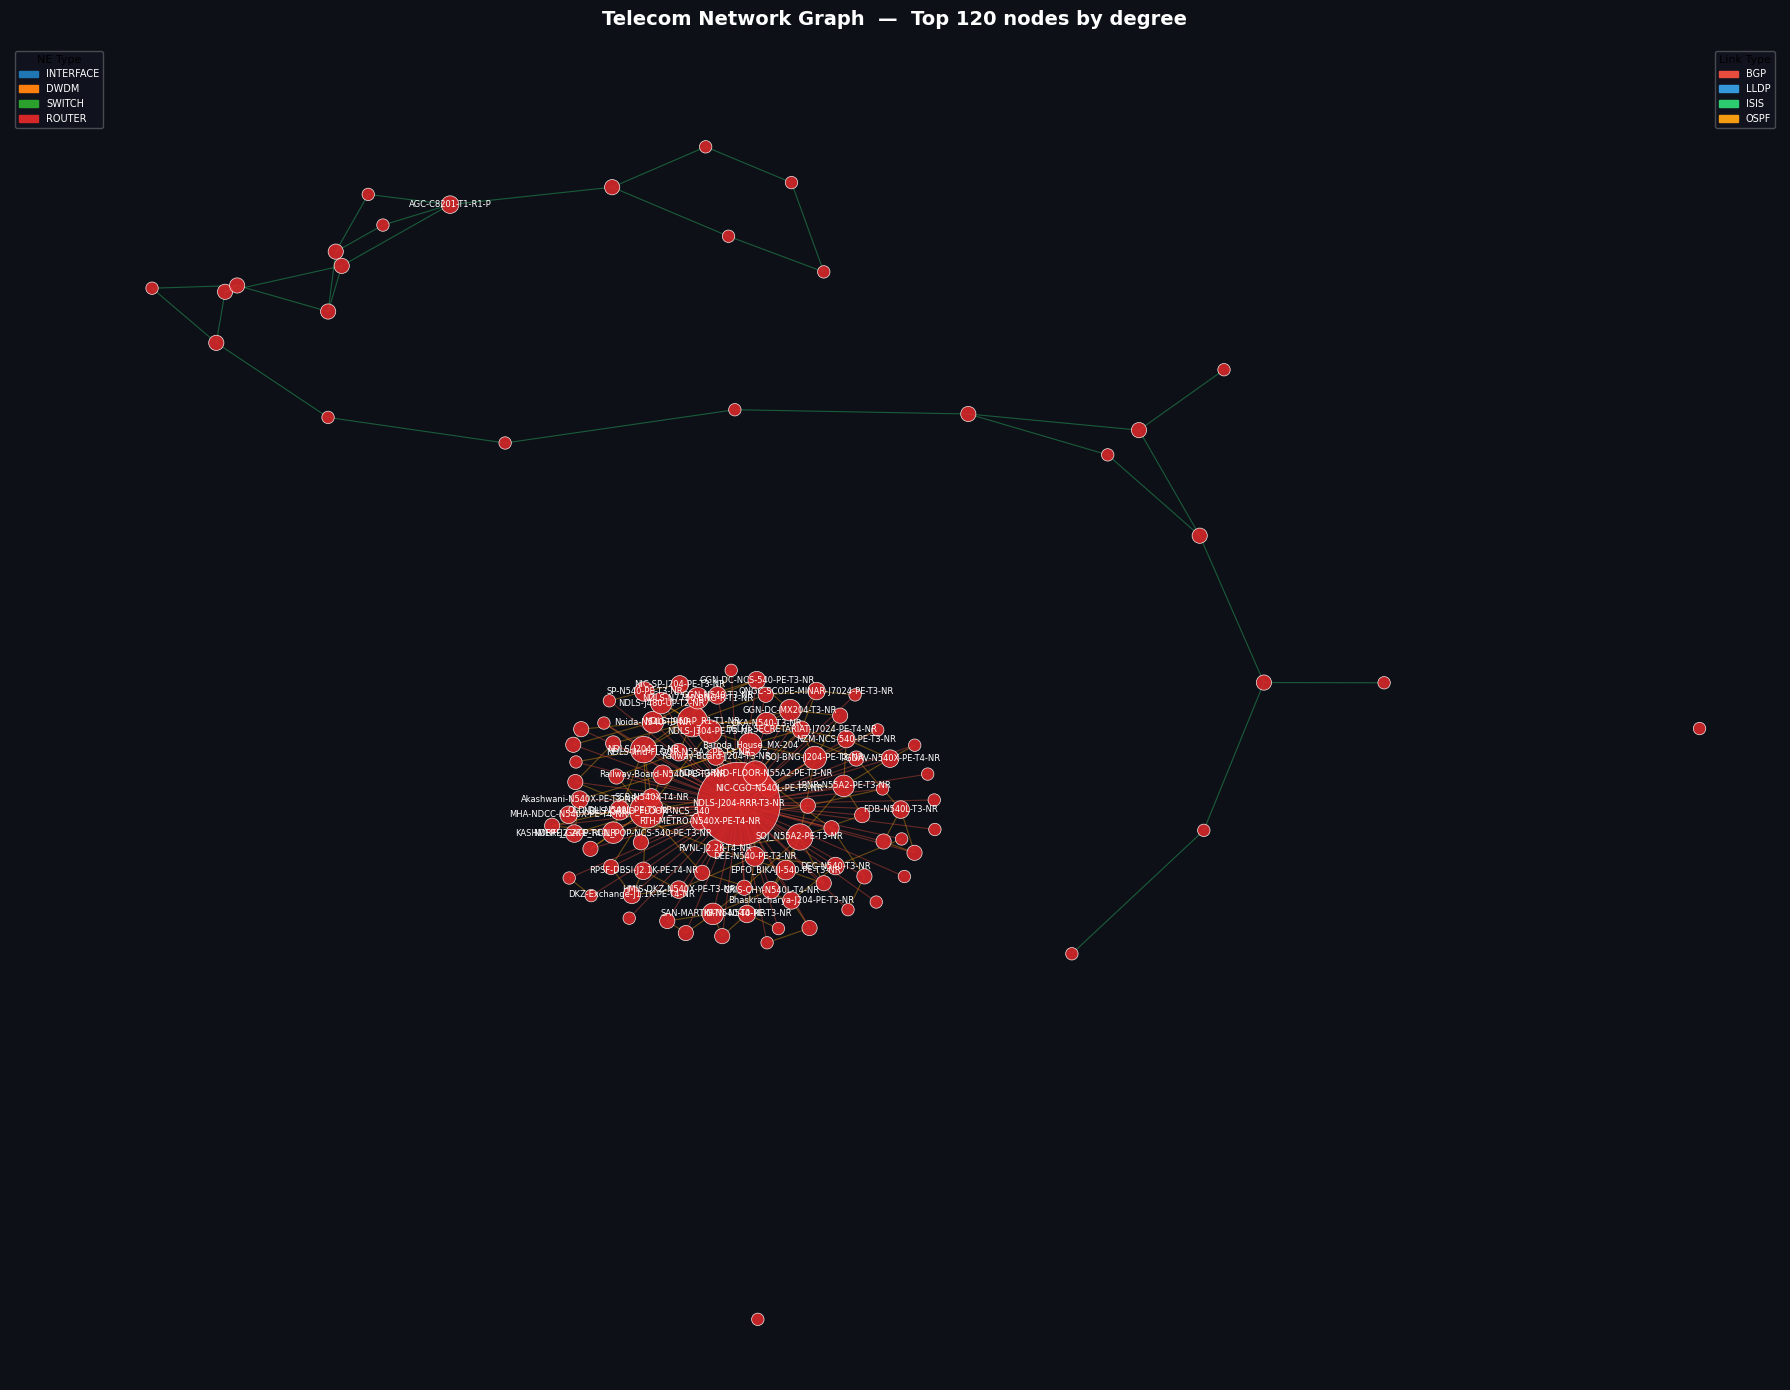

Saved → network_graph_static.png


In [45]:

# ============================================================
# GRAPH VISUALIZATION 2 — NetworkX + Matplotlib (Static)
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Rebuild ne_id_to_idx with ID/NE_ID/IP so link table integer FKs resolve (viz runnable standalone)
ne_id_to_idx_viz = dict(zip(ne_clean['NE_ID'].astype(str), np.arange(len(ne_clean))))
if 'ID' in ne_clean.columns:
    for i, pk in enumerate(ne_clean['ID'].values):
        if pk is not None and pd.notna(pk):
            try:
                ne_id_to_idx_viz[pk] = ne_id_to_idx_viz[int(pk)] = ne_id_to_idx_viz[str(int(pk))] = i
            except (ValueError, TypeError):
                pass
if 'IP_ADDRESS' in ne_clean.columns:
    for i, ip in enumerate(ne_clean['IP_ADDRESS'].astype(str).values):
        if ip and ip not in ('UNKNOWN', '0', 'nan'):
            ne_id_to_idx_viz[ip] = i
ne_id_to_idx = ne_id_to_idx_viz

# Build NetworkX graph
G = nx.Graph()

ne_names  = ne_clean['NE_NAME'].astype(str).values
ne_types  = ne_clean['NE_TYPE'].astype(str).values  if 'NE_TYPE'  in ne_clean.columns else ['UNKNOWN'] * len(ne_names)
ne_vendor = ne_clean['VENDOR'].astype(str).values   if 'VENDOR'   in ne_clean.columns else ['UNKNOWN'] * len(ne_names)

for i, (name, ntype, vendor) in enumerate(zip(ne_names, ne_types, ne_vendor)):
    G.add_node(i, name=name, ne_type=ntype, vendor=vendor)

topo_colors = {
    'bgp_link' : '#e74c3c',
    'lldp_link': '#3498db',
    'isis_link': '#2ecc71',
    'ospf_link': '#f39c12',
}

for tname in topo_colors:
    df = data.get(tname, pd.DataFrame())
    if df.empty:
        continue
    src_col = 'SOURCE_INTERFACE_NE_ID' if tname == 'lldp_link' and 'SOURCE_INTERFACE_NE_ID' in df.columns else 'SOURCE_NE_ID'
    dst_col = 'DESTINATION_INTERFACE_NE_ID' if tname == 'lldp_link' and 'DESTINATION_INTERFACE_NE_ID' in df.columns else 'DESTINATION_NE_ID'
    if src_col not in df.columns or dst_col not in df.columns:
        continue
    s = df[src_col].map(ne_id_to_idx)
    d = df[dst_col].map(ne_id_to_idx)
    valid = s.notna() & d.notna() & (s != d)
    for si, di in zip(s[valid].astype(int), d[valid].astype(int)):
        if not G.has_edge(si, di):
            G.add_edge(si, di, topo=tname)

print(f"Graph built — Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")

# Subgraph: top-N nodes by degree for readability
MAX_VIZ       = min(120, G.number_of_nodes())
top_nodes_viz = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:MAX_VIZ]
top_ids_viz   = [n for n, _ in top_nodes_viz]
G_sub         = G.subgraph(top_ids_viz)

pos = nx.spring_layout(G_sub, seed=42, k=1.5 / max(1, MAX_VIZ ** 0.5))

unique_types   = list(set(ne_types))
palette        = plt.cm.tab10.colors
type_color_map = {t: palette[i % len(palette)] for i, t in enumerate(unique_types)}

node_colors = [type_color_map.get(G_sub.nodes[n].get('ne_type', 'UNKNOWN'), 'grey') for n in G_sub.nodes]
node_sizes  = [max(80, G_sub.degree(n) * 40) for n in G_sub.nodes]
e_colors    = [topo_colors.get(d.get('topo', ''), '#aaaaaa') for u, v, d in G_sub.edges(data=True)]

fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

nx.draw_networkx_edges(G_sub, pos, edge_color=e_colors, alpha=0.4, width=0.8, ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, linewidths=0.5, edgecolors='white', ax=ax)

# Labels only on top-30 hub nodes
deg_sorted      = sorted([G_sub.degree(n) for n in G_sub.nodes], reverse=True)
label_threshold = deg_sorted[min(29, len(deg_sorted) - 1)]
labels = {n: G_sub.nodes[n].get('name', str(n))
          for n in G_sub.nodes if G_sub.degree(n) >= label_threshold}
nx.draw_networkx_labels(G_sub, pos, labels, font_size=6, font_color='white', ax=ax)

node_legend = [mpatches.Patch(color=type_color_map[t], label=t) for t in unique_types]
edge_legend = [mpatches.Patch(color=c, label=t.replace('_link', '').upper()) for t, c in topo_colors.items()]

leg1 = ax.legend(handles=node_legend, title='NE Type',   loc='upper left',  fontsize=7,
                 framealpha=0.3, labelcolor='white', title_fontsize=8, facecolor='#1a1a2e')
leg2 = ax.legend(handles=edge_legend, title='Link Type', loc='upper right', fontsize=7,
                 framealpha=0.3, labelcolor='white', title_fontsize=8, facecolor='#1a1a2e')
ax.add_artist(leg1)

ax.set_title(f"Telecom Network Graph  —  Top {MAX_VIZ} nodes by degree",
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('network_graph_static.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Saved → network_graph_static.png")


In [46]:

# ============================================================
# GRAPH VISUALIZATION 3 — PyVis Interactive HTML
# ============================================================
# pip install pyvis   (if not installed)

try:
    from pyvis.network import Network
    PYVIS_OK = True
except ImportError:
    PYVIS_OK = False
    print("pyvis not installed. Run:  pip install pyvis")

if PYVIS_OK:
    import networkx as nx

    # Use a subgraph — PyVis is browser-based; cap at 300 nodes for speed
    MAX_NODES = min(300, node_feats.shape[0])

    # Pick highest-degree nodes (most connected = most relevant for RCA)
    G_tmp = nx.Graph()
    if edge_index.shape[1] > 0:
        G_tmp.add_edges_from(edge_index.t().tolist())
    top_nodes = sorted(G_tmp.degree(), key=lambda x: x[1], reverse=True)[:MAX_NODES]
    top_node_ids = set(n for n, _ in top_nodes)

    ne_names = ne_clean['NE_NAME'].astype(str).values
    ne_types = ne_clean['NE_TYPE'].astype(str).values if 'NE_TYPE' in ne_clean.columns else ['UNKNOWN'] * len(ne_names)

    # Color map by NE_TYPE
    unique_types = list(set(ne_types))
    color_palette = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
                     '#edc948','#b07aa1','#ff9da7','#9c755f','#bab0ac']
    type_color = {t: color_palette[i % len(color_palette)] for i, t in enumerate(unique_types)}

    net = Network(
        height='700px', width='100%',
        bgcolor='#1a1a2e', font_color='white',
        notebook=True, cdn_resources='remote'
    )
    net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=120)

    # Add nodes
    for node_id in top_node_ids:
        ne_name  = ne_names[node_id] if node_id < len(ne_names) else f"Node {node_id}"
        ne_type  = ne_types[node_id] if node_id < len(ne_types) else 'UNKNOWN'
        color    = type_color.get(ne_type, '#aaaaaa')
        degree   = G_tmp.degree(node_id) if node_id in G_tmp else 0
        size     = max(8, min(30, degree * 2))  # bigger = more connected

        net.add_node(
            node_id,
            label=ne_name,
            title=f"NE: {ne_name}<br>Type: {ne_type}<br>Degree: {degree}",
            color=color,
            size=size
        )

    # Add edges between top nodes only
    added_edges = set()
    for src, dst in edge_index.t().tolist():
        if src in top_node_ids and dst in top_node_ids:
            key = (min(src, dst), max(src, dst))
            if key not in added_edges:
                net.add_edge(src, dst, color='rgba(255,255,255,0.15)', width=1)
                added_edges.add(key)

    # Legend info in title
    net.set_options("""
    var options = {
      "edges": { "smooth": { "type": "continuous" } },
      "interaction": { "hover": true, "tooltipDelay": 100 },
      "physics": { "stabilization": { "iterations": 100 } }
    }
    """)

    output_file = 'network_graph_interactive.html'
    net.show(output_file)

    print(f"Interactive graph saved → {output_file}")
    print(f"Nodes shown : {len(top_node_ids)}")
    print(f"Edges shown : {len(added_edges)}")
    print(f"\nNE_TYPE color legend:")
    for t, c in type_color.items():
        count = sum(1 for x in ne_types[:MAX_NODES] if x == t)
        print(f"  {c}  {t:30s} ({count} nodes)")


network_graph_interactive.html
Interactive graph saved → network_graph_interactive.html
Nodes shown : 300
Edges shown : 658

NE_TYPE color legend:
  #4e79a7  INTERFACE                      (287 nodes)
  #f28e2b  DWDM                           (0 nodes)
  #e15759  SWITCH                         (0 nodes)
  #76b7b2  ROUTER                         (13 nodes)


        NETWORK GRAPH STATISTICS
  Nodes             :   59,667
  Edges             :    1,330
  Avg degree        :     0.04
  Max degree        :      299
  Connected comps   :    58818
  Graph density     :   0.0000


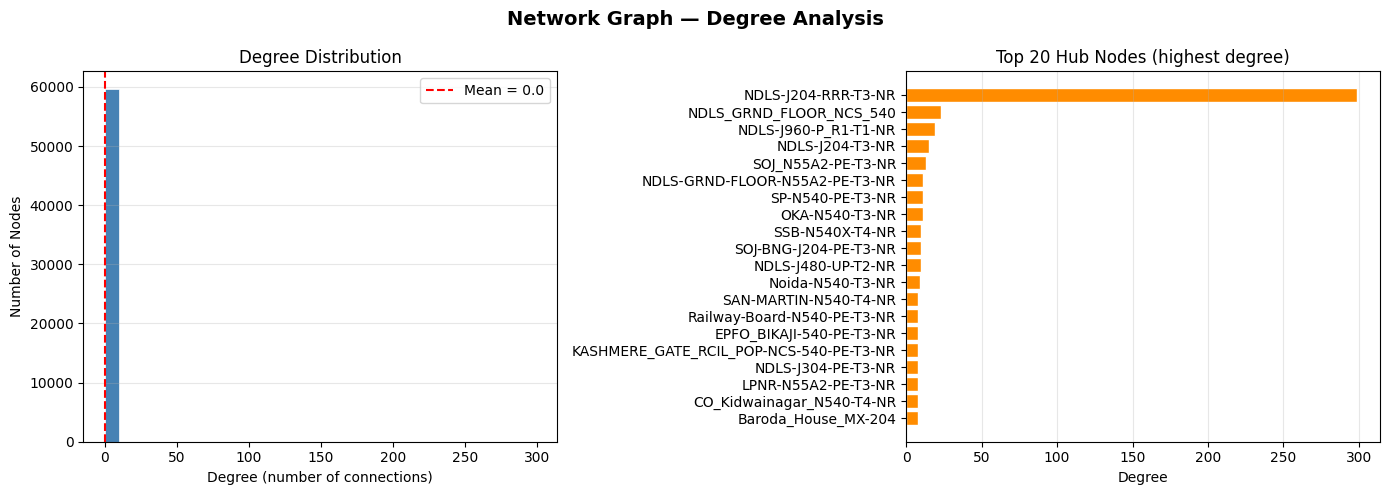

Saved → graph_degree_analysis.png


In [47]:

# ============================================================
# GRAPH VISUALIZATION 4 — Graph Statistics Summary
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Build NetworkX graph from graph_data for stats
G_stats = nx.Graph()
G_stats.add_nodes_from(range(node_feats.shape[0]))

if edge_index.shape[1] > 0:
    edges = edge_index.t().tolist()
    G_stats.add_edges_from(edges)

# --- Core Stats ---
degrees      = [d for _, d in G_stats.degree()]
n_nodes      = G_stats.number_of_nodes()
n_edges      = G_stats.number_of_edges()
avg_degree   = np.mean(degrees) if degrees else 0
max_degree   = max(degrees) if degrees else 0
n_components = nx.number_connected_components(G_stats)
density      = nx.density(G_stats)

print("=" * 45)
print("        NETWORK GRAPH STATISTICS")
print("=" * 45)
print(f"  Nodes             : {n_nodes:>8,}")
print(f"  Edges             : {n_edges:>8,}")
print(f"  Avg degree        : {avg_degree:>8.2f}")
print(f"  Max degree        : {max_degree:>8}")
print(f"  Connected comps   : {n_components:>8}")
print(f"  Graph density     : {density:>8.4f}")
print("=" * 45)

# --- Degree Distribution Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Network Graph — Degree Analysis", fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(degrees, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(avg_degree, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {avg_degree:.1f}')
axes[0].set_title("Degree Distribution")
axes[0].set_xlabel("Degree (number of connections)")
axes[0].set_ylabel("Number of Nodes")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Top-20 highest-degree nodes (hub nodes = most connected = likely critical for RCA)
ne_names    = ne_clean['NE_NAME'].astype(str).values
node_deg    = sorted(enumerate(degrees), key=lambda x: x[1], reverse=True)[:20]
top_names   = [ne_names[i] if i < len(ne_names) else f"Node {i}" for i, _ in node_deg]
top_degrees = [d for _, d in node_deg]

axes[1].barh(top_names[::-1], top_degrees[::-1], color='darkorange', edgecolor='white')
axes[1].set_title("Top 20 Hub Nodes (highest degree)")
axes[1].set_xlabel("Degree")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_degree_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → graph_degree_analysis.png")


## PHASE 4 — Temporal Dataset

For each labeled incident:
- Sort alarms by `OPEN_TIME`
- Map each alarm `ENTITY_NAME` → NE encoder → node index
- Compute relative time from first alarm (seconds)
- Record event sequence: `(node_idx, rel_time, severity_score)`
- Label = root cause node index from `labels_df`

Output: list of `(node_features, edge_index, event_seq, label_idx)` tuples  
Split: 70% train / 15% val / 15% test

In [48]:

# ============================================================
# PHASE 4 — TEMPORAL DATASET CREATION + TRAIN/VAL/TEST SPLIT
# ============================================================

import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

severity_map = {'CRITICAL': 4, 'MAJOR': 3, 'MINOR': 2, 'WARNING': 1, 'INFO': 0}

# NE name → integer index (consistent with graph node order)
ne_encoder = LabelEncoder()
ne_encoder.fit(ne_clean['NE_NAME'].astype(str).values)
print(f"Total network elements (nodes): {len(ne_encoder.classes_)}")

# Build dataset: list of (node_features, edge_index, event_sequence, label_idx)
temporal_dataset = []
skipped = 0

labeled_incidents = labels_df['INCIDENT_ID'].unique()

for inc_id in labeled_incidents:
    inc_alarms = alarm_clean[alarm_clean['INCIDENT_ID'] == inc_id].copy()
    inc_alarms = inc_alarms.sort_values('OPEN_TIME').reset_index(drop=True)

    if len(inc_alarms) < 2:
        skipped += 1
        continue

    # Build event sequence: (node_idx, relative_time_seconds, severity_score)
    t0     = inc_alarms['OPEN_TIME'].iloc[0]
    events = []
    for _, row in inc_alarms.iterrows():
        ne_name = str(row.get('ENTITY_NAME', ''))
        if ne_name not in ne_encoder.classes_:
            continue
        node_idx = int(ne_encoder.transform([ne_name])[0])
        rel_t    = (row['OPEN_TIME'] - t0).total_seconds()
        sev      = severity_map.get(str(row.get('SEVERITY', 'WARNING')), 1)
        events.append((node_idx, rel_t, sev))

    if len(events) < 2:
        skipped += 1
        continue

    # Get root cause label (node index)
    root_row = labels_df[labels_df['INCIDENT_ID'] == inc_id]
    if root_row.empty:
        skipped += 1
        continue

    root_ne_name = str(root_row.iloc[0]['ROOT_NE_NAME'])
    if root_ne_name not in ne_encoder.classes_:
        skipped += 1
        continue

    label_idx = int(ne_encoder.transform([root_ne_name])[0])

    temporal_dataset.append((
        graph_data.x.clone(),       # node features  [num_nodes, num_features]
        graph_data.edge_index,      # graph topology [2, num_edges]
        events,                     # alarm event sequence
        label_idx                   # root cause node index
    ))

print(f"Dataset samples built : {len(temporal_dataset)}")
print(f"Skipped               : {skipped}")

# Train / Val / Test split  (70 / 15 / 15)
indices = list(range(len(temporal_dataset)))

if len(indices) >= 6:
    train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)
    val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, random_state=42)
else:
    # Tiny dataset fallback
    train_idx = val_idx = test_idx = indices

print(f"\nTrain : {len(train_idx)}")
print(f"Val   : {len(val_idx)}")
print(f"Test  : {len(test_idx)}")


Total network elements (nodes): 59667


KeyboardInterrupt: 

## PHASE 5 — TGAT Model

Temporal Graph Attention Network for node-level root cause classification.

Architecture:
- `TimeEncoding` — learnable sinusoidal frequencies encode relative alarm time
- `MultiheadAttention × 2` — attend over all nodes (graph context)
- `FFN + LayerNorm` — stabilize and refine embeddings
- `Linear → sigmoid` — per-node root cause probability [0, 1]

Training:
- Loss: Binary Cross Entropy (label=1 for root node, 0 for all others)
- Optimizer: Adam (lr=0.001) + ReduceLROnPlateau
- Metrics: Acc@1 (exact match), Acc@3 (root in top-3 predictions)

In [ ]:

# ============================================================
# PHASE 5 — TGAT MODEL ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import os

os.makedirs('model', exist_ok=True)


class TimeEncoding(nn.Module):
    """Learnable functional time encoding using sinusoidal basis."""
    def __init__(self, dim=64):
        super().__init__()
        self.omega = nn.Parameter(torch.randn(dim // 2))
        self.dim   = dim

    def forward(self, t):
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=torch.float32)
        t      = t.float()
        angles = t.unsqueeze(-1) * self.omega.unsqueeze(0)   # [N, dim//2]
        return torch.cat([torch.cos(angles), torch.sin(angles)], dim=-1)  # [N, dim]


class TGAT(nn.Module):
    """
    Temporal Graph Attention Network for node-level RCA.

    Flow:
        node_features + time_encoding
            → projection
            → multi-head self-attention (layer 1)  [captures graph context]
            → multi-head self-attention (layer 2)
            → feed-forward network
            → per-node sigmoid score (root cause probability)
    """
    def __init__(self, in_dim, hidden_dim=128, heads=4, time_dim=64):
        super().__init__()
        self.time_enc = TimeEncoding(time_dim)
        self.in_proj  = nn.Linear(in_dim + time_dim, hidden_dim)

        self.attn1 = nn.MultiheadAttention(hidden_dim, heads, batch_first=True, dropout=0.1)
        self.attn2 = nn.MultiheadAttention(hidden_dim, heads, batch_first=True, dropout=0.1)

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )
        self.norm3 = nn.LayerNorm(hidden_dim)
        self.out   = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        """
        x          : [num_nodes, in_dim]
        edge_index : [2, num_edges]
        returns    : [num_nodes, 1]  — probability per node
        """
        num_nodes = x.shape[0]

        # Time encoding: node order as temporal proxy
        t     = torch.arange(num_nodes, dtype=torch.float32)
        t_enc = self.time_enc(t)                          # [num_nodes, time_dim]

        h = torch.cat([x, t_enc], dim=-1)                # [num_nodes, in_dim + time_dim]
        h = F.relu(self.in_proj(h))                       # [num_nodes, hidden_dim]

        # Attention layer 1
        h_seq  = h.unsqueeze(0)                           # [1, num_nodes, hidden_dim]
        h2, _  = self.attn1(h_seq, h_seq, h_seq)
        h      = self.norm1(h + h2.squeeze(0))

        # Attention layer 2
        h_seq  = h.unsqueeze(0)
        h2, _  = self.attn2(h_seq, h_seq, h_seq)
        h      = self.norm2(h + h2.squeeze(0))

        # FFN
        h = self.norm3(h + self.ffn(h))

        return torch.sigmoid(self.out(h))                 # [num_nodes, 1]


# Instantiate model
in_features = graph_data.x.shape[1]
tgat_model  = TGAT(in_dim=in_features, hidden_dim=128, heads=4, time_dim=64)

total_params = sum(p.numel() for p in tgat_model.parameters())
print(f"TGAT model initialized")
print(f"Input features  : {in_features}")
print(f"Hidden dim      : 128  |  Heads: 4  |  Time dim: 64")
print(f"Total parameters: {total_params:,}")
print()
print(tgat_model)


In [ ]:

# ============================================================
# PHASE 5 — TRAINING LOOP
# ============================================================

from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(tgat_model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=False)
criterion = torch.nn.BCELoss()


def run_epoch(split_indices, train=True):
    if train:
        tgat_model.train()
    else:
        tgat_model.eval()

    total_loss, correct_at1, correct_at3, total = 0, 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for idx in split_indices:
            node_feats, edge_index, event_seq, label_idx = temporal_dataset[idx]

            if label_idx < 0 or label_idx >= node_feats.shape[0]:
                continue

            x = node_feats.clone()
            for node_i, rel_t, sev in event_seq:
                if node_i < x.shape[0]:
                    x[node_i, -2] = sev
                    x[node_i, -1] = 1.0 / (1 + rel_t / 60.0)

            out    = tgat_model(x, edge_index).squeeze()
            target = torch.zeros(out.shape[0])
            target[label_idx] = 1.0

            loss = criterion(out, target)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total      += 1

            scores = out.detach().cpu().numpy()
            top1   = scores.argmax()
            top3   = scores.argsort()[::-1][:3]

            if top1 == label_idx:       correct_at1 += 1
            if label_idx in top3:       correct_at3 += 1

    n = max(total, 1)
    return total_loss / n, correct_at1 / n, correct_at3 / n


EPOCHS       = 30
best_val_loss = float('inf')
history      = {'train_loss': [], 'val_loss': [], 'val_acc@1': [], 'val_acc@3': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Acc@1':>7} | {'Acc@3':>7}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    tr_loss, _, _        = run_epoch(train_idx, train=True)
    val_loss, acc1, acc3 = run_epoch(val_idx,   train=False)

    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc@1'].append(acc1)
    history['val_acc@3'].append(acc3)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(tgat_model.state_dict(), 'model/tgat_rca.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {val_loss:>8.4f} | {acc1:>7.2%} | {acc3:>7.2%}")

print(f"\nBest val loss : {best_val_loss:.4f}")
print("Best model saved → model/tgat_rca.pt")

# Load best checkpoint for inference
tgat_model.load_state_dict(torch.load('model/tgat_rca.pt'))
print("Best model loaded.")

# Final test set evaluation
test_loss, test_acc1, test_acc3 = run_epoch(test_idx, train=False)
print(f"\nTest Acc@1 : {test_acc1:.2%}")
print(f"Test Acc@3 : {test_acc3:.2%}")
print(f"Test Loss  : {test_loss:.4f}")


## PHASE 6 — Inference Engine

RCA prediction on a new/live incident alarm batch:
- Map alarms to graph nodes via NE encoder
- Inject alarm activity (severity + recency) into node features
- Run TGAT forward pass → probability per node
- Post-process → root cause + impacted services + location
- Output: structured RCA JSON report

In [ ]:

# ============================================================
# PHASE 6 — INFERENCE ENGINE
# ============================================================

def predict_rca(incident_alarms_df, model, graph_data, ne_encoder, severity_map, top_k=3):
    """
    Input  : DataFrame of alarms for ONE incident
    Output : Top-K root cause nodes with confidence scores
    """
    model.eval()
    with torch.no_grad():
        incident_alarms_df = incident_alarms_df.sort_values('OPEN_TIME')
        t0 = incident_alarms_df['OPEN_TIME'].iloc[0]

        events = []
        for _, row in incident_alarms_df.iterrows():
            ne_name = str(row.get('ENTITY_NAME', ''))
            if ne_name not in ne_encoder.classes_:
                continue
            node_idx = ne_encoder.transform([ne_name])[0]
            rel_time = (row['OPEN_TIME'] - t0).total_seconds()
            severity = severity_map.get(str(row.get('SEVERITY', 'WARNING')), 1)
            events.append((node_idx, rel_time, severity))

        if not events:
            return []

        x = graph_data.x.clone()
        for node_idx, rel_time, severity in events:
            if node_idx < x.shape[0]:
                x[node_idx, -2] = severity
                x[node_idx, -1] = 1.0 / (1 + rel_time / 60.0)

        out    = tgat_model(x, graph_data.edge_index)
        scores = out.squeeze().cpu().numpy()

        top_indices = scores.argsort()[::-1][:top_k]
        results = []
        for rank, idx in enumerate(top_indices):
            ne_name = ne_encoder.inverse_transform([idx])[0]
            results.append({
                'rank'      : rank + 1,
                'ne_id'     : int(idx),
                'ne_name'   : ne_name,
                'confidence': float(round(scores[idx], 4))
            })
    return results


def build_rca_report(incident_id, predictions, alarm_df, ne_df, ns_df, ckt_df):
    """Build final RCA JSON output."""
    if not predictions:
        return {'incident_id': incident_id, 'error': 'No root cause found'}

    root         = predictions[0]
    root_ne_name = root['ne_name']

    incident_alarms = alarm_df[alarm_df['INCIDENT_ID'] == incident_id]
    ckt_ids  = incident_alarms['CKT_ID'].dropna().unique().tolist()
    services = ns_df[ns_df['CKT_ID'].isin(ckt_ids)]['NETWORK_SERVICE_NAME'].dropna().unique().tolist() if not ns_df.empty else []

    ne_row   = ne_df[ne_df['NE_NAME'] == root_ne_name]
    location = ne_row['GEOGRAPHY_L1_NAME'].values[0] if (len(ne_row) > 0 and 'GEOGRAPHY_L1_NAME' in ne_row.columns) else 'Unknown'

    return {
        'incident_id'      : incident_id,
        'root_cause_ne'    : root_ne_name,
        'confidence'       : root['confidence'],
        'top_candidates'   : predictions,
        'impacted_services': services,
        'location'         : location,
        'alarm_count'      : len(incident_alarms),
        'alarm_types'      : incident_alarms['ALARM_NAME'].value_counts().head(3).to_dict()
    }


# --- Quick test on a sample incident ---
if len(labels_df) > 0:
    sample_incident = labels_df['INCIDENT_ID'].iloc[0]
    sample_alarms   = alarm_clean[alarm_clean['INCIDENT_ID'] == sample_incident]

    preds  = predict_rca(sample_alarms, tgat_model, graph_data, ne_encoder, severity_map)
    report = build_rca_report(
        sample_incident, preds, alarm_clean, ne_clean,
        data.get('network_service', pd.DataFrame()),
        data.get('ckt_id_info', pd.DataFrame())
    )

    import json
    print(json.dumps(report, indent=2))
else:
    print("No labels available — skipping inference test.")


In [ ]:

import json

notebook_path = r"D:\project\client_project\experiment01.ipynb"

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook = json.load(f)

# Extract cell information
cells_info = []
for cell in notebook.get('cells', []):
    cell_id = cell.get('id', 'NO_ID')
    cell_type = cell.get('cell_type', 'unknown')
    
    # Get source code (first 3 lines)
    source = cell.get('source', [])
    if isinstance(source, list):
        source_text = ''.join(source)
    else:
        source_text = source
    
    source_lines = source_text.split('\n')[:3]
    source_snippet = '\n'.join(source_lines)
    
    # Get outputs
    outputs = cell.get('outputs', [])
    error_info = None
    
    for output in outputs:
        if output.get('output_type') == 'error':
            error_info = {
                'ename': output.get('ename'),
                'evalue': output.get('evalue'),
                'traceback': output.get('traceback', [])
            }
            break
    
    cells_info.append({
        'cell_id': cell_id,
        'cell_type': cell_type,
        'source_snippet': source_snippet,
        'error': error_info if error_info else 'OK'
    })

# Print results
for i, cell in enumerate(cells_info, 1):
    print(f"\n{'='*80}")
    print(f"Cell #{i} | ID: {cell['cell_id']} | Type: {cell['cell_type']}")
    print(f"{'='*80}")
    print(f"Source (first 3 lines):\n{cell['source_snippet']}")
    print(f"\nError Status: {cell['error'] if cell['error'] == 'OK' else 'ERROR'}")
    
    if cell['error'] != 'OK':
        print(f"\nException Type: {cell['error']['ename']}")
        print(f"Exception Value: {cell['error']['evalue']}")
        print(f"\nTraceback:")
        traceback_text = ''.join(cell['error']['traceback'])
        print(traceback_text)

print(f"\n\n{'='*80}")
print(f"SUMMARY: Total cells = {len(cells_info)}")
error_cells = [c for c in cells_info if c['error'] != 'OK']
print(f"Cells with errors = {len(error_cells)}")



Cell #1 | ID: 429caefc | Type: markdown
Source (first 3 lines):
# Database Connection

Error Status: OK

Cell #2 | ID: 18aeb4f6 | Type: code
Source (first 3 lines):
import pandas as pd
import mysql.connector


Error Status: OK

Cell #3 | ID: ce3fcc25 | Type: code
Source (first 3 lines):
import pandas as pd

pd.set_option('display.max_rows', None)

Error Status: OK

Cell #4 | ID: 9991bc87 | Type: code
Source (first 3 lines):
query = "SHOW TABLES"
tables = pd.read_sql(query, conn)


Error Status: OK

Cell #5 | ID: 73b16ecf | Type: code
Source (first 3 lines):
import pandas as pd

tables = pd.read_sql("SHOW TABLES", conn)

Error Status: OK

Cell #6 | ID: beaa5177 | Type: markdown
Source (first 3 lines):
# FILTER REQUIRED TABLES
## alarm
## network_element

Error Status: OK

Cell #7 | ID: 74834ec0 | Type: code
Source (first 3 lines):
required_tables = [
    "alarm",
    "network_element",

Error Status: OK

Cell #8 | ID: bfe1a5bc | Type: code
Source (first 3 lines):
data = {}

for table i